# Immobilier Tunisien — Pipeline Data Science
### `NLP → Nettoyage → Prédiction de Prix`

---
**Structure du notebook**
```
PARTIE 1 — NLP          : détection pays, extraction features depuis le texte brut
PARTIE 2 — NETTOYAGE    : prix, surface, doublons, feature engineering
PARTIE 3 — PRÉDICTION   : pipeline sklearn, 4 modèles, cross-validation, ensemble
```

In [1]:
# ── Dépendances (Colab les a déjà, juste au cas où)
# !pip install openpyxl scikit-learn -q

import pandas as pd
import numpy as np
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.0f}'.format)

print('✓ Imports OK')

✓ Imports OK


In [12]:
# ── Chemin du fichier (déjà uploadé dans le panneau Files de Colab)
# Le fichier 'final_listings_report (1).xlsx' doit être visible dans Files (à gauche)

# ── Upload du fichier Excel ──
from google.colab import files

print('📂 Clique sur "Choisir des fichiers" ci-dessous')
uploaded = files.upload()  # ← un bouton va apparaître ici

FILE_PATH = list(uploaded.keys())[0]
print(f'✓ Fichier chargé : {FILE_PATH}')

📂 Clique sur "Choisir des fichiers" ci-dessous


Saving final_listings_report (1).xlsx to final_listings_report (1).xlsx
✓ Fichier chargé : final_listings_report (1).xlsx


In [13]:
df_raw = pd.read_excel(FILE_PATH)
print(f'Shape : {df_raw.shape}')
df_raw.head(3)

Shape : (3680, 19)


,website_id,title,price,currency,city,zone,property_type,transaction_type,surface_m2,rooms,bathrooms,description,agency_owner,phone,listing_url,data_hash,image_urls,published_date,scraped_at
0,698b18a6c43bfefaf2694c1e,À vendre appartement S+2 Ain Zaghouan Nord - 1...,1,TND,Tunis,NaN,NaN,NaN,115,0,0,NaN,NaN,NaN,https://century21.tn/property/a-vendre-apparte...,4262fa565db01f790e98080dc698ec35,['https://century21.tn/wp-content/uploads/What...,NaN,2026-02-10 21:01:30.841
1,698b18a6c43bfefaf2694c1e,À vendre duplex S+3 Jardins de Carthage - 307 m²,1,TND,Tunis,NaN,NaN,NaN,307,0,0,NaN,NaN,NaN,https://century21.tn/property/a-vendre-duplex-...,b9b8581e5189e7059877a8424d47a018,['https://century21.tn/wp-content/uploads/What...,NaN,2026-02-10 21:01:34.661
2,698b18a6c43bfefaf2694c1e,À vendre appartement S+2 La Soukra - 113 m²,1,TND,Tunis,NaN,NaN,NaN,113,0,0,NaN,NaN,NaN,https://century21.tn/property/a-vendre-apparte...,9e6f5b4dbc3b7ae4834b8ee301439a5d,['https://century21.tn/wp-content/uploads/c704...,NaN,2026-02-10 21:01:38.071


---
## PARTIE 1 — NLP
### Objectif : extraire de l'information structurée depuis du texte brut

Les colonnes `property_type`, `transaction_type`, `zone` sont **vides dans la source**.
On les reconstruit depuis le titre et l'URL via :
- **Détection de pays** : domaine TLD + keywords
- **Regex** : patterns `S+N`, `NNN m²`, `/a-vendre`
- **Dictionnaire** : mapping lexical pour le type de bien

```
Titre brut : "À vendre appartement S+2 Ain Zaghouan Nord - 115 m²"
             ──────┬──────  ─────┬──────  ──┬──  ──────┬──────   ─┬─
                   │             │           │          │           │
          transaction         type        rooms       zone      surface
```

In [14]:
# ════════════════════════════════════════════════════════════
#  1.1 — DÉTECTION DE PAYS (signal domaine + fallback NLP)
# ════════════════════════════════════════════════════════════

# Domaines officiellement étrangers dans notre dataset
FR_DOMAINS = re.compile(r'century21\.fr|green-acres\.fr|seloger|leboncoin|pap\.fr', re.I)
MA_DOMAINS = re.compile(r'mubawab\.ma', re.I)
TN_DOMAINS = re.compile(r'\.tn$|\.com\.tn$', re.I)

# Keywords NLP pour trancher les domaines ambigus (.com, .net...)
TN_KW = [
    'tunis','ariana','nabeul','sousse','sfax','monastir','mahdia','hammamet',
    'djerba','carthage','la marsa','berges du lac','ennasr','menzah','chotrana',
    'soukra','ain zaghouan','kairouan','bizerte','mednine','tataouine','gabes',
    'gabès','kef','tozeur','gafsa','jendouba','beja','sidi bouzid','ben arous',
    'manouba','tnd','montplaisir','sidi daoud','mrezga','sahloul','kerkennah',
    'zarzis','sidi bou said','el aouina','cite ennasr','jardins de carthage',
]
MA_KW = [
    'marrakech','casablanca','rabat','agadir','fes','tanger','kenitra',
    'oujda','hivernage','maroc','dh ','mad ',
]
FR_KW = [
    'paris','lyon','marseille','bordeaux','toulouse','nice','nantes','strasbourg',
    'montpellier','rennes','lille','grenoble','limoges','dijon','troyes','rouen',
    'reims','amiens','caen','argenteuil','bretagne','basque',' euros ',' € ',
]

def detect_country(row) -> str:
    """
    Retourne 'TN' | 'FR' | 'MA' | 'OTHER'

    Priorité : domaine TLD → keywords MA/FR → keywords TN
    """
    url    = str(row.get('listing_url', '') or '')
    m      = re.match(r'https?://(?:www\.)?([^/]+)', url)
    domain = m.group(1).lower() if m else ''
    text   = ' '.join([
        str(row.get('title', '')       or ''),
        str(row.get('description', '') or ''),
        str(row.get('city', '')        or ''),
    ]).lower()

    # Signal fort : TLD du domaine
    if TN_DOMAINS.search(domain):  return 'TN'
    if FR_DOMAINS.search(domain):  return 'FR'
    if MA_DOMAINS.search(domain):  return 'MA'

    # Fallback NLP sur le texte (pour les .com, .net...)
    if any(kw in text for kw in MA_KW): return 'MA'
    if any(kw in text for kw in FR_KW): return 'FR'
    if any(kw in text for kw in TN_KW): return 'TN'
    if str(row.get('currency', '')).upper() == 'TND': return 'TN'

    return 'OTHER'  # inclassable → on garde (peut être TN sans indice fort)

Distribution pays détectés :
country
TN    2688
MA     523
FR     469


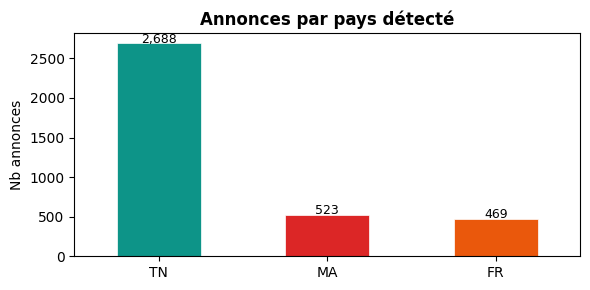

In [15]:
df_raw['country'] = df_raw.apply(detect_country, axis=1)

print('Distribution pays détectés :')
print(df_raw['country'].value_counts().to_string())

fig, ax = plt.subplots(figsize=(6, 3))
vc = df_raw['country'].value_counts()
colors = ['#0D9488','#DC2626','#EA580C','#6B7280']
vc.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Annonces par pays détecté', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Nb annonces')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height() + 10),
                ha='center', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# ════════════════════════════════════════════════════════════
#  1.2 — EXTRACTION NLP DES FEATURES DEPUIS LE TITRE
# ════════════════════════════════════════════════════════════

# --- transaction_type ---
def extract_transaction(title: str, url: str = '') -> str:
    """
    Détecte Vente / Location depuis le titre et l'URL.
    L'URL est plus fiable : /a-vendre, /a-louer
    """
    src = (str(title or '') + ' ' + str(url or '')).lower()
    if re.search(r'\bvendr[e]?\b|\bvente\b|\bvend\b|a[ -]vendre|/a-vendre', src):
        return 'Vente'
    if re.search(r'\bloue[r]?\b|\blocation\b|a[ -]louer|/a-louer', src):
        return 'Location'
    return 'Inconnu'


# --- property_type ---
PROPERTY_DICT = {
    'appartement': 'Appartement', 'duplex':  'Duplex',    'triplex': 'Triplex',
    'penthouse':   'Penthouse',   'studio':  'Studio',    'loft':    'Loft',
    'villa':       'Villa',       'maison':  'Maison',    'riad':    'Riad',
    'bureau':      'Bureau',      'local':   'Local com', 'magasin': 'Magasin',
    'entrepôt':    'Entrepôt',    'entrepot':'Entrepôt',  'hangar':  'Hangar',
    'immeuble':    'Immeuble',    'terrain': 'Terrain',   'ferme':   'Ferme',
    'parking':     'Parking',     'garage':  'Garage',
}

def extract_property_type(title: str, url: str = '') -> str:
    src = (str(title or '') + ' ' + str(url or '')).lower()
    for key, val in PROPERTY_DICT.items():
        if key in src:
            return val
    return 'Autre'


# --- rooms depuis pattern S+N ---
def extract_rooms(title: str) -> float | None:
    """
    S+2 → 3 pièces  |  H+3 (bureaux) → 4 pièces
    """
    t = str(title or '').upper()
    m = re.search(r'\bS\s*\+\s*(\d+)\b', t)
    if m: return int(m.group(1)) + 1
    m = re.search(r'\b[HA]\s*\+\s*(\d+)\b', t)   # bureaux : H+2, A+3
    if m: return int(m.group(1)) + 1
    return None


# --- surface depuis titre ou description ---
def extract_surface(title: str, description: str = '') -> float | None:
    """
    Cherche 'NNN m²' dans le titre d'abord, puis dans la description.
    Filtre : 5 ≤ surface ≤ 20 000 m²
    """
    for src in [str(title or ''), str(description or '')]:
        m = re.search(r'(\d[\d\s]*)\s*m[²2]', src, re.IGNORECASE)
        if m:
            try:
                v = int(re.sub(r'\s', '', m.group(1)))
                if 5 <= v <= 20_000:
                    return float(v)
            except ValueError:
                pass
    return None


# --- zone / quartier ---
def extract_zone(title: str) -> str | None:
    """
    Extrait le quartier depuis le pattern :
    'Appartement S+2  <ZONE>  - 115 m²'
    """
    t = str(title or '')
    m = re.search(
        r'(?:S\+\d+|[HA]\+\d+|studio|duplex|villa|appartement)\s+(.+?)'
        r'(?:\s*[-–]\s*\d+\s*m[²2]|$)',
        t, re.IGNORECASE
    )
    if m:
        zone = re.sub(r'\d+\s*m[²2].*', '', m.group(1), flags=re.IGNORECASE).strip('- ')
        if 3 <= len(zone) <= 60 and not re.match(r'^\d+$', zone):
            return zone
    return None

In [17]:
# Application sur le dataset brut (avant filtrage géographique)
# → on applique NLP sur tout, on filtre après

df_raw['_transaction_nlp'] = df_raw.apply(
    lambda r: extract_transaction(r['title'], r.get('listing_url', '')), axis=1
)
df_raw['_property_nlp'] = df_raw.apply(
    lambda r: extract_property_type(r['title'], r.get('listing_url', '')), axis=1
)
df_raw['_rooms_nlp']   = df_raw['title'].apply(extract_rooms)
df_raw['_surface_nlp'] = df_raw.apply(
    lambda r: extract_surface(r['title'], r.get('description', '')), axis=1
)
df_raw['_zone_nlp'] = df_raw['title'].apply(extract_zone)

# Résumé NLP
n = len(df_raw)
print('─── Taux de couverture NLP (sur tout le dataset) ───')
print(f"  transaction_type : {(df_raw['_transaction_nlp'] != 'Inconnu').sum():>5} / {n}  "
      f"({(df_raw['_transaction_nlp'] != 'Inconnu').mean()*100:.1f}%)")
print(f"  property_type    : {(df_raw['_property_nlp'] != 'Autre').sum():>5} / {n}  "
      f"({(df_raw['_property_nlp'] != 'Autre').mean()*100:.1f}%)")
print(f"  rooms (S+N)      : {df_raw['_rooms_nlp'].notna().sum():>5} / {n}  "
      f"({df_raw['_rooms_nlp'].notna().mean()*100:.1f}%)")
print(f"  surface (m²)     : {df_raw['_surface_nlp'].notna().sum():>5} / {n}  "
      f"({df_raw['_surface_nlp'].notna().mean()*100:.1f}%)")
print(f"  zone/quartier    : {df_raw['_zone_nlp'].notna().sum():>5} / {n}  "
      f"({df_raw['_zone_nlp'].notna().mean()*100:.1f}%)")

─── Taux de couverture NLP (sur tout le dataset) ───
  transaction_type :  2314 / 3680  (62.9%)
  property_type    :  2855 / 3680  (77.6%)
  rooms (S+N)      :   545 / 3680  (14.8%)
  surface (m²)     :   519 / 3680  (14.1%)
  zone/quartier    :  1265 / 3680  (34.4%)


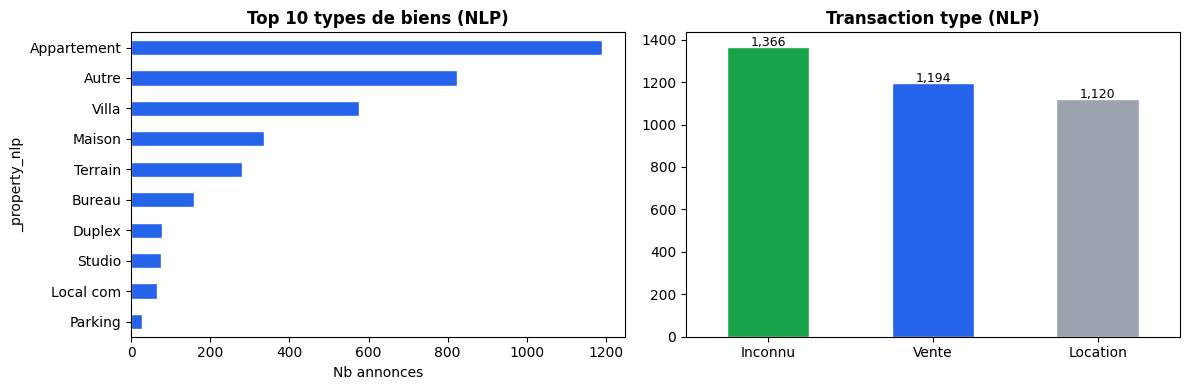

In [18]:
# Visualisation : distribution des types de biens extraits
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# property_type
pt = df_raw['_property_nlp'].value_counts().head(10)
pt.plot(kind='barh', ax=axes[0], color='#2563EB', edgecolor='white')
axes[0].set_title('Top 10 types de biens (NLP)', fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('Nb annonces')

# transaction_type
tt = df_raw['_transaction_nlp'].value_counts()
colors_tt = ['#16A34A', '#2563EB', '#9CA3AF']
tt.plot(kind='bar', ax=axes[1], color=colors_tt, edgecolor='white')
axes[1].set_title('Transaction type (NLP)', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_xticklabels(tt.index, rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## PARTIE 2 — NETTOYAGE
### Objectif : produire un dataset fiable pour le ML

Pipeline de nettoyage :
```
① Filtrage géographique   → on garde uniquement la Tunisie
② Merge NLP → colonnes    → on consolide les features extraites
③ Nettoyage prix          → règles métier par type de transaction
④ Nettoyage surface       → bornes physiques réalistes
⑤ Déduplication           → hash exact + (titre, prix)
⑥ Feature engineering     → 10 nouvelles colonnes pour le ML
```

In [19]:
# ════════════════════════════════════════════════════════════
#  2.1 — FILTRAGE GÉOGRAPHIQUE
# ════════════════════════════════════════════════════════════

df = df_raw[df_raw['country'].isin(['TN', 'OTHER'])].copy()

removed = df_raw[~df_raw['country'].isin(['TN', 'OTHER'])]
print(f'Supprimés : {len(removed)} annonces non-tunisiennes')
print(removed['country'].value_counts().to_string())
print(f'\nDataset Tunisie : {len(df)} annonces')

Supprimés : 992 annonces non-tunisiennes
country
MA    523
FR    469

Dataset Tunisie : 2688 annonces


In [20]:
# ════════════════════════════════════════════════════════════
#  2.2 — CONSOLIDATION : colonnes existantes + NLP
# ════════════════════════════════════════════════════════════
#
# Règle : valeur source garde la priorité si elle est non-nulle.
# Si nulle → on prend la valeur extraite par NLP.

# transaction_type & property_type : toutes nulles en source → 100% NLP
df['transaction_type'] = df['_transaction_nlp']
df['property_type']    = df['_property_nlp']

# rooms : source a des 0 qu'on traite comme null
rooms_src = pd.to_numeric(df['rooms'], errors='coerce').replace(0, np.nan)
df['rooms'] = rooms_src.combine_first(df['_rooms_nlp'])

# surface : même logique
surf_src = pd.to_numeric(df['surface_m2'], errors='coerce').replace(0, np.nan)
df['surface_m2'] = surf_src.combine_first(df['_surface_nlp'])

# zone
df['zone'] = df['zone'].combine_first(df['_zone_nlp'])

# Normalisation ville
CITY_MAP = {
    'tunis':'Tunis','ariana':'Ariana','ben arous':'Ben Arous','nabeul':'Nabeul',
    'sousse':'Sousse','sfax':'Sfax','monastir':'Monastir','mahdia':'Mahdia',
    'hammamet':'Hammamet','djerba':'Djerba','bizerte':'Bizerte','kairouan':'Kairouan',
    'gabes':'Gabès','gabès':'Gabès','mednine':'Médenine','tataouine':'Tataouine',
    'gafsa':'Gafsa','tozeur':'Tozeur','la marsa':'La Marsa','manouba':'Manouba',
    'zaghouan':'Zaghouan','sidi bouzid':'Sidi Bouzid','jendouba':'Jendouba',
}
def normalize_city(c):
    if pd.isna(c): return np.nan
    cl = str(c).lower().strip()
    for k, v in CITY_MAP.items():
        if k in cl: return v
    return str(c).strip().title()

df['city'] = df['city'].apply(normalize_city)

# Nettoyage colonnes intermédiaires NLP
df.drop(columns=[c for c in df.columns if c.startswith('_')], inplace=True)

print('Consolidation terminée.')
print(df[['transaction_type','property_type','rooms','surface_m2','zone','city']].info())

Consolidation terminée.
<class 'pandas.core.frame.DataFrame'>
Index: 2688 entries, 0 to 3679
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_type  2688 non-null   object 
 1   property_type     2688 non-null   object 
 2   rooms             1319 non-null   float64
 3   surface_m2        2202 non-null   float64
 4   zone              835 non-null    object 
 5   city              2619 non-null   object 
dtypes: float64(2), object(4)
memory usage: 211.5+ KB
None


In [21]:
# ════════════════════════════════════════════════════════════
#  2.3 — NETTOYAGE DES PRIX
# ════════════════════════════════════════════════════════════
#
# Règles métier (en TND) :
#   Vente    : [15 000 — 10 000 000]
#   Location : [200   — 100 000]
#   Inconnu  : [200   — 10 000 000]

PRICE_BOUNDS = {
    'Vente':    (15_000, 10_000_000),
    'Location': (200,    100_000),
    'Inconnu':  (200,    10_000_000),
}

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['price_original'] = df['price'].copy()  # conservation de la valeur brute

def clean_price(row):
    p, t = row['price'], row['transaction_type']
    if pd.isna(p) or p <= 0:
        return np.nan
    lo, hi = PRICE_BOUNDS.get(t, (200, 10_000_000))
    return p if lo <= p <= hi else np.nan

df['price'] = df.apply(clean_price, axis=1)

# Diagnostique
n_total  = len(df)
n_valid  = df['price'].notna().sum()
n_null   = df['price_original'].isna().sum() + (df['price_original'] <= 0).sum()
n_bounds = n_total - n_valid - n_null

print(f'Prix valides : {n_valid:,} / {n_total:,}')
print(f'Null / zéro  : {n_null:,}')
print(f'Hors bornes  : {n_bounds:,}')
print()
print('Statistiques prix valides (Vente) :')
print(df[df['transaction_type']=='Vente']['price'].describe().apply('{:,.0f}'.format))

Prix valides : 1,482 / 2,688
Null / zéro  : 550
Hors bornes  : 656

Statistiques prix valides (Vente) :
count           402
mean        700,483
std       1,021,759
min          15,600
25%         250,000
50%         450,000
75%         796,000
max      10,000,000
Name: price, dtype: object


In [22]:
# ════════════════════════════════════════════════════════════
#  2.4 — NETTOYAGE SURFACE + DÉDUPLICATION
# ════════════════════════════════════════════════════════════

df['surface_m2'] = pd.to_numeric(df['surface_m2'], errors='coerce')
df.loc[(df['surface_m2'] <= 0) | (df['surface_m2'] > 15_000), 'surface_m2'] = np.nan

n_before = len(df)
df = df.drop_duplicates(subset='data_hash')
df = df.drop_duplicates(subset=['title', 'price'], keep='first')
n_dupes = n_before - len(df)

print(f'Doublons supprimés : {n_dupes}')
print(f'Dataset final      : {len(df):,} annonces')

Doublons supprimés : 552
Dataset final      : 2,136 annonces


In [23]:
# ════════════════════════════════════════════════════════════
#  2.5 — FEATURE ENGINEERING
# ════════════════════════════════════════════════════════════
#
# On crée des features informatives pour le modèle ML.
# Chaque feature a une justification métier.

# F1 : prix au m² — indicateur de valeur relatif
df['price_per_m2'] = np.where(
    df['price'].notna() & df['surface_m2'].notna() & (df['surface_m2'] > 0),
    df['price'] / df['surface_m2'],
    np.nan
)

# F2 : log(surface) — la surface a une distribution log-normale
df['log_surface'] = np.log1p(df['surface_m2'].fillna(0))

# F3 : pièces imputées — S+N depuis titre, sinon surface/25 (heuristique)
df['rooms_imp'] = df['rooms'].fillna(
    (df['surface_m2'].fillna(0) / 25).round().clip(1, 12)
)

# F4 : SDB imputées
df['bath_imp'] = df['bathrooms'].replace(0, np.nan).fillna(
    (df['rooms_imp'] / 3).round().clip(0, 5)
)

# F5 : prix/m² médian par type de bien — proxy de la valeur du segment
pm2_by_type = (
    df[df['price_per_m2'].between(100, 30_000)]
    .groupby('property_type')['price_per_m2'].median()
)
df['ref_pm2'] = df['property_type'].map(pm2_by_type).fillna(df['price_per_m2'].median())

# F6 : bucket surface (catégoriel ordonné)
df['surface_cat'] = pd.cut(
    df['surface_m2'],
    bins=[0, 50, 80, 120, 200, 400, 20_000],
    labels=['<50m²','50-80','80-120','120-200','200-400','>400m²']
).astype(str).replace('nan', 'Inconnu')

# F7-F9 : flags textuels (meublé, neuf, piscine)
df['is_furnished'] = df['title'].str.contains(r'meublé|meuble', case=False, na=False).astype(int)
df['is_new']       = df['title'].str.contains(r'\bneuf\b|\bneuve\b|\bstanding\b', case=False, na=False).astype(int)
df['has_pool']     = df.apply(
    lambda r: int(bool(re.search(r'piscine|pool',
                                  str(r['title'] or '') + str(r.get('description','') or ''),
                                  re.I))),
    axis=1
)

# F10 : tier de la ville (liquidité du marché)
CITY_TIER = {
    'Tunis': 1, 'Ariana': 1, 'La Marsa': 1,
    'Ben Arous': 2, 'Nabeul': 2, 'Hammamet': 2, 'Sousse': 2, 'Sfax': 2,
    'Monastir': 2, 'Mahdia': 3, 'Bizerte': 3, 'Kairouan': 3,
    'Djerba': 3, 'Gabès': 3,
}
df['city_tier'] = df['city'].map(CITY_TIER).fillna(4).astype(int)

print('Features engineering — aperçu :')
fe_cols = ['price_per_m2','log_surface','rooms_imp','bath_imp','ref_pm2',
           'surface_cat','is_furnished','is_new','has_pool','city_tier']
print(df[fe_cols].describe().round(2).T[['count','mean','min','max']].to_string())

Features engineering — aperçu :
              count  mean  min       max
price_per_m2  1,052 7,690    0 2,100,000
log_surface   2,136     4    0        10
rooms_imp     2,136    13    1     1,700
bath_imp      2,136     2    0         5
ref_pm2       2,136 2,168  549     5,841
is_furnished  2,136     0    0         1
is_new        2,136     0    0         1
has_pool      2,136     0    0         1
city_tier     2,136     1    1         4


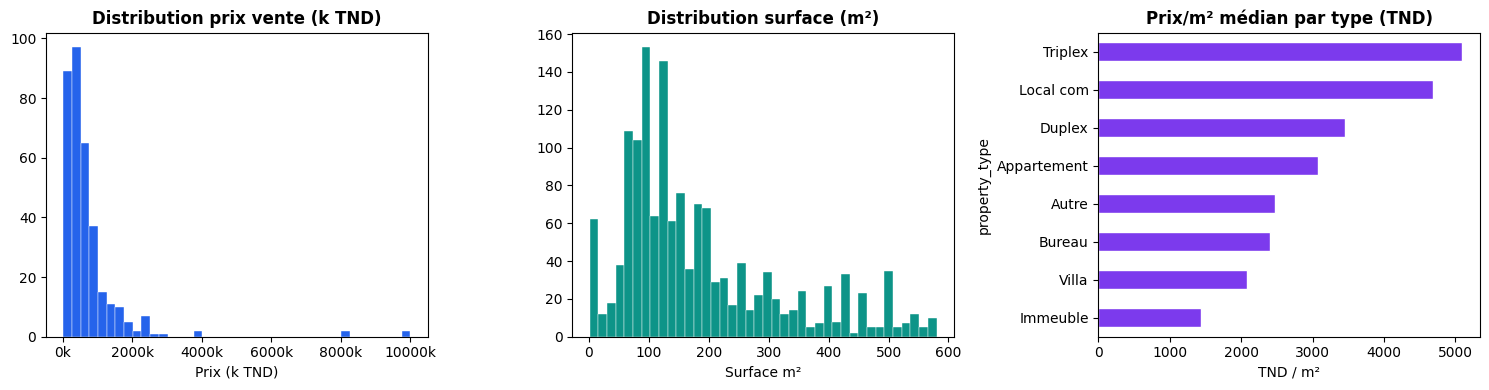


✓ Dataset nettoyé : 2,136 annonces
  dont Vente    : 714
  dont Location : 590


In [24]:
# Visualisation du dataset nettoyé
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution prix (vente)
df_v = df[(df['transaction_type']=='Vente') & df['price'].notna()]
axes[0].hist(df_v['price'] / 1000, bins=40, color='#2563EB', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution prix vente (k TND)', fontweight='bold')
axes[0].set_xlabel('Prix (k TND)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

# Distribution surface
df_s = df[df['surface_m2'].notna() & (df['surface_m2'] < 600)]
axes[1].hist(df_s['surface_m2'], bins=40, color='#0D9488', edgecolor='white', linewidth=0.3)
axes[1].set_title('Distribution surface (m²)', fontweight='bold')
axes[1].set_xlabel('Surface m²')

# Prix/m² par type de bien
pm2_plot = (
    df[df['price_per_m2'].between(100, 15_000) & (df['transaction_type']=='Vente')]
    .groupby('property_type')['price_per_m2'].median()
    .sort_values(ascending=False)
    .head(8)
)
pm2_plot.plot(kind='barh', ax=axes[2], color='#7C3AED', edgecolor='white')
axes[2].set_title('Prix/m² médian par type (TND)', fontweight='bold')
axes[2].invert_yaxis()
axes[2].set_xlabel('TND / m²')

plt.tight_layout()
plt.show()

print(f'\n✓ Dataset nettoyé : {len(df):,} annonces')
print(f'  dont Vente    : {(df["transaction_type"]=="Vente").sum():,}')
print(f'  dont Location : {(df["transaction_type"]=="Location").sum():,}')

---
## PARTIE 3 — PRÉDICTION DE PRIX
### Objectif : entraîner un modèle qui prédit le prix d'un bien

Architecture du pipeline :
```
                         ┌─────────────────────────┐
Raw features             │   ColumnTransformer     │
  ├── numériques   ──►   │   ├── Imputer (median)  │
  └── catégoriels  ──►   │   └── OneHotEncoder     │   ──►  Model
                         └─────────────────────────┘
```

**Modèles évalués**
| Modèle | Type | Avantage |
|---|---|---|
| Random Forest | Ensemble bagging | Robuste au bruit, stable |
| Extra Trees | Ensemble bagging | Plus rapide, moins variance |
| Gradient Boosting | Ensemble boosting | Meilleur sur données tabulaires |
| Huber Regressor | Linéaire robuste | Résistant aux outliers |

**Sélection finale** : VotingRegressor (moyenne des top 3 modèles)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, VotingRegressor)
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

print('✓ Sklearn importé')

✓ Sklearn importé


In [26]:
# ════════════════════════════════════════════════════════════
#  3.1 — PRÉPARATION DU DATASET ML
# ════════════════════════════════════════════════════════════
#
# On travaille sur les VENTES uniquement :
# → prix unique (pas de récurrence mensuelle)
# → plus grande variance de prix → plus facile à modéliser

FEATURES_NUM = [
    'surface_m2',    # surface brute
    'log_surface',   # surface log-transformée (distribution plus symétrique)
    'rooms_imp',     # nb pièces
    'bath_imp',      # nb SDB
    'ref_pm2',       # prix/m² médian du segment (feature la plus prédictive)
    'city_tier',     # tier de la ville (1-4)
    'is_furnished',  # meublé : flag 0/1
    'is_new',        # neuf   : flag 0/1
    'has_pool',      # piscine : flag 0/1
]
FEATURES_CAT = [
    'property_type',  # Appartement, Villa, Terrain...
    'surface_cat',    # bucket surface
]

# Filtrage : vente + prix valide + surface valide
df_ml = df[
    (df['transaction_type'] == 'Vente') &
    df['price'].notna() &
    df['surface_m2'].notna() &
    (df['surface_m2'] > 10)
].copy()

# Suppression outliers prix : IQR [10% — 90%]
p10, p90 = df_ml['price'].quantile([0.10, 0.90])
df_ml = df_ml[(df_ml['price'] >= p10) & (df_ml['price'] <= p90)]

# Suppression prix/m² aberrants
df_ml = df_ml[df_ml['price_per_m2'].between(100, 25_000)]

X = df_ml[FEATURES_NUM + FEATURES_CAT]
y = df_ml['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Dataset ML (vente) : {len(df_ml)} annonces')
print(f'Train : {len(X_train)} | Test : {len(X_test)}')
print(f'Target — min: {y.min():,.0f} TND | médiane: {y.median():,.0f} TND | max: {y.max():,.0f} TND')

Dataset ML (vente) : 258 annonces
Train : 206 | Test : 52
Target — min: 140,000 TND | médiane: 460,000 TND | max: 1,400,000 TND


In [27]:
# ════════════════════════════════════════════════════════════
#  3.2 — CONSTRUCTION DU PIPELINE SKLEARN
# ════════════════════════════════════════════════════════════

# Preprocessing numérique : imputation médiane + standardisation
num_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Preprocessing catégoriel : imputation mode + OHE
cat_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_preprocessor, FEATURES_NUM),
    ('cat', cat_preprocessor, FEATURES_CAT),
])

# Modèles candidats
MODELS = {
    'RandomForest':    RandomForestRegressor(
                            n_estimators=400, max_depth=10,
                            min_samples_leaf=2, random_state=42, n_jobs=-1),
    'ExtraTrees':      ExtraTreesRegressor(
                            n_estimators=400, max_depth=10,
                            min_samples_leaf=2, random_state=42, n_jobs=-1),
    'GradientBoosting':GradientBoostingRegressor(
                            n_estimators=300, max_depth=4,
                            learning_rate=0.05, subsample=0.8, random_state=42),
    'HuberRegressor':  HuberRegressor(epsilon=1.35, max_iter=500),
}

print('Pipeline sklearn construit :')
print(f'  Features numériques  : {FEATURES_NUM}')
print(f'  Features catégoriels : {FEATURES_CAT}')
print(f'  Modèles à évaluer    : {list(MODELS.keys())}')

Pipeline sklearn construit :
  Features numériques  : ['surface_m2', 'log_surface', 'rooms_imp', 'bath_imp', 'ref_pm2', 'city_tier', 'is_furnished', 'is_new', 'has_pool']
  Features catégoriels : ['property_type', 'surface_cat']
  Modèles à évaluer    : ['RandomForest', 'ExtraTrees', 'GradientBoosting', 'HuberRegressor']


In [28]:
# ════════════════════════════════════════════════════════════
#  3.3 — ENTRAÎNEMENT + CROSS-VALIDATION
# ════════════════════════════════════════════════════════════

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in MODELS.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])

    # Cross-validation sur le train set (estimation non-biaisée)
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')

    # Fit final + évaluation test
    pipe.fit(X_train, y_train)
    y_pred = np.clip(pipe.predict(X_test), 0, None)

    results[name] = {
        'pipeline': pipe,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std':  cv_r2.std(),
        'R2':   r2_score(y_test, y_pred),
        'MAE':  mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    }
    print(f"{name:<20}  CV-R²={results[name]['cv_r2_mean']:.3f}(±{results[name]['cv_r2_std']:.3f})"
          f"  Test-R²={results[name]['R2']:.3f}  MAE={results[name]['MAE']:,.0f} TND")

RandomForest          CV-R²=0.148(±0.128)  Test-R²=0.209  MAE=203,995 TND
ExtraTrees            CV-R²=0.071(±0.186)  Test-R²=-0.013  MAE=222,387 TND
GradientBoosting      CV-R²=-0.121(±0.274)  Test-R²=0.136  MAE=213,132 TND
HuberRegressor        CV-R²=0.157(±0.152)  Test-R²=0.203  MAE=199,287 TND


In [29]:
# ════════════════════════════════════════════════════════════
#  3.4 — ENSEMBLE : VotingRegressor (top 3 modèles)
# ════════════════════════════════════════════════════════════
#
# Le VotingRegressor fait la moyenne des prédictions.
# En général : réduit la variance sans augmenter le biais.

top3 = sorted(results, key=lambda k: results[k]['R2'], reverse=True)[:3]
print(f'Top 3 modèles sélectionnés pour l\'ensemble : {top3}')

ensemble = VotingRegressor(
    estimators=[(name, results[name]['pipeline']) for name in top3]
)
ensemble.fit(X_train, y_train)

y_ens   = np.clip(ensemble.predict(X_test), 0, None)
ens_r2  = r2_score(y_test, y_ens)
ens_mae = mean_absolute_error(y_test, y_ens)
ens_rmse= np.sqrt(mean_squared_error(y_test, y_ens))

print(f'\n🏆 Ensemble — R²={ens_r2:.3f}  MAE={ens_mae:,.0f} TND  RMSE={ens_rmse:,.0f} TND')

Top 3 modèles sélectionnés pour l'ensemble : ['RandomForest', 'HuberRegressor', 'GradientBoosting']

🏆 Ensemble — R²=0.237  MAE=200,100 TND  RMSE=263,703 TND


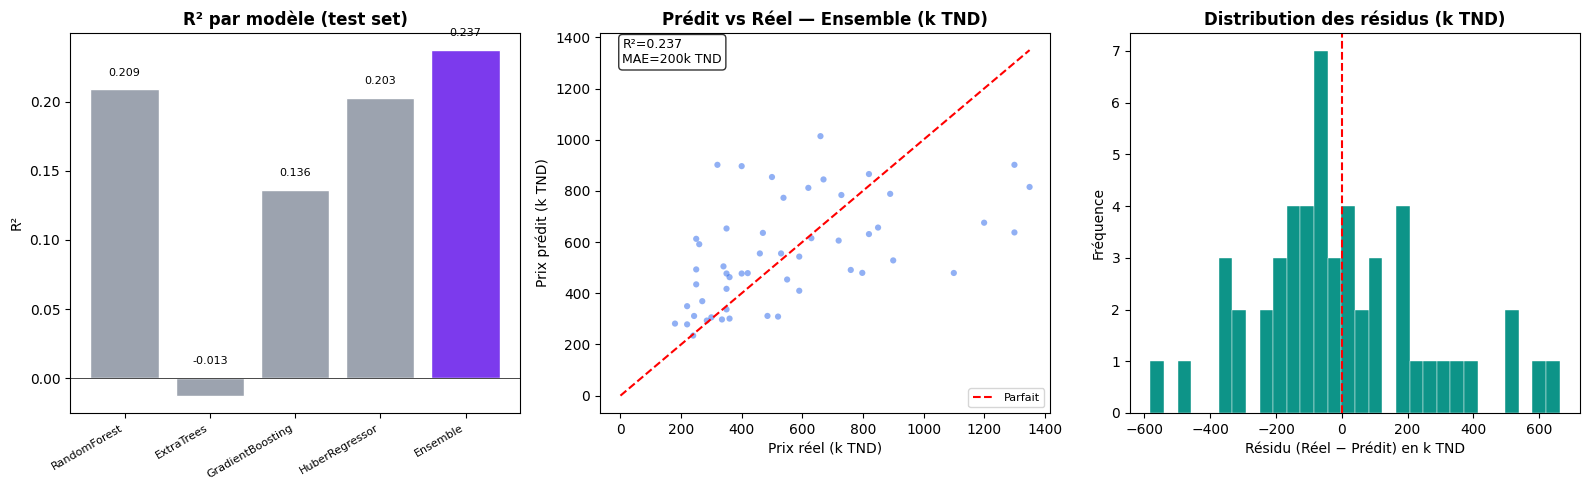

In [30]:
# ════════════════════════════════════════════════════════════
#  3.5 — VISUALISATION DES RÉSULTATS
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Comparaison modèles ──
model_names = list(results.keys()) + ['Ensemble']
r2_vals     = [results[m]['R2'] for m in results] + [ens_r2]
mae_vals    = [results[m]['MAE'] for m in results] + [ens_mae]
colors_bar  = ['#9CA3AF'] * len(results) + ['#7C3AED']

bars = axes[0].bar(range(len(model_names)), r2_vals, color=colors_bar, edgecolor='white')
axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels(model_names, rotation=30, ha='right', fontsize=8)
axes[0].set_title('R² par modèle (test set)', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, max(val, 0) + 0.01,
                 f'{val:.3f}', ha='center', fontsize=8)

# ── Predicted vs Actual ──
axes[1].scatter(y_test / 1000, y_ens / 1000,
                alpha=0.5, s=20, color='#2563EB', edgecolors='none')
lim = max(y_test.max(), y_ens.max()) / 1000
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Parfait')
axes[1].set_title('Prédit vs Réel — Ensemble (k TND)', fontweight='bold')
axes[1].set_xlabel('Prix réel (k TND)')
axes[1].set_ylabel('Prix prédit (k TND)')
axes[1].legend(fontsize=8)
axes[1].text(0.05, 0.92, f'R²={ens_r2:.3f}\nMAE={ens_mae/1000:.0f}k TND',
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ── Distribution des résidus ──
residuals = y_test.values - y_ens
axes[2].hist(residuals / 1000, bins=30, color='#0D9488', edgecolor='white', linewidth=0.3)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Distribution des résidus (k TND)', fontweight='bold')
axes[2].set_xlabel('Résidu (Réel − Prédit) en k TND')
axes[2].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

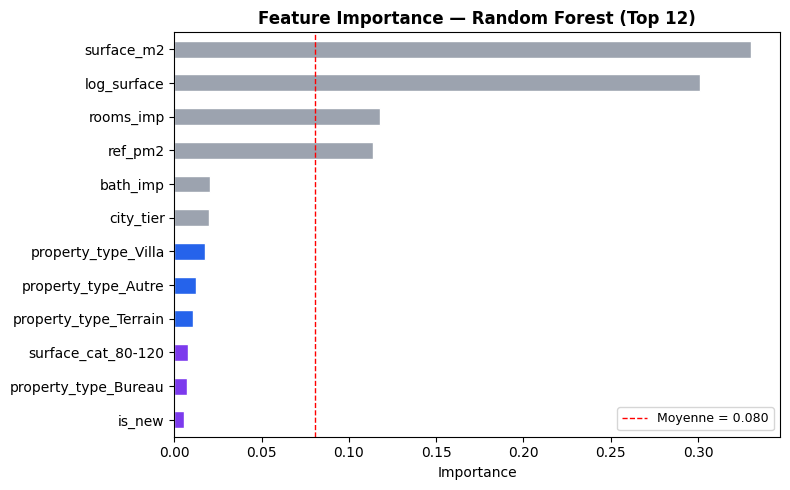

Top 5 features les plus importantes :
  surface_m2                0.3305  (33.0%)
  log_surface               0.3011  (30.1%)
  rooms_imp                 0.1179  (11.8%)
  ref_pm2                   0.1136  (11.4%)
  bath_imp                  0.0205  (2.1%)


In [31]:
# ════════════════════════════════════════════════════════════
#  3.6 — FEATURE IMPORTANCE (Random Forest)
# ════════════════════════════════════════════════════════════

rf_pipe   = results['RandomForest']['pipeline']
rf_model  = rf_pipe.named_steps['model']
pre_step  = rf_pipe.named_steps['pre']
ohe_names = list(pre_step.transformers_[1][1]
                 .named_steps['ohe']
                 .get_feature_names_out(FEATURES_CAT))
all_feat_names = FEATURES_NUM + ohe_names

fi = pd.Series(rf_model.feature_importances_, index=all_feat_names)
fi_top = fi.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
colors_fi = ['#7C3AED' if i < 3 else '#2563EB' if i < 6 else '#9CA3AF'
             for i in range(len(fi_top))]
fi_top.plot(kind='barh', ax=ax, color=colors_fi[::-1], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Feature Importance — Random Forest (Top 12)', fontweight='bold')
ax.set_xlabel('Importance')
ax.axvline(fi_top.mean(), color='red', linestyle='--', linewidth=1, label=f'Moyenne = {fi_top.mean():.3f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Top 5 features les plus importantes :')
for feat, imp in fi_top.head(5).items():
    print(f'  {feat:<25} {imp:.4f}  ({imp*100:.1f}%)')

In [32]:
# ════════════════════════════════════════════════════════════
#  3.7 — PRÉDICTION SUR NOUVEAUX BIENS
# ════════════════════════════════════════════════════════════

def predict_price(surface_m2: float,
                  property_type: str = 'Appartement',
                  rooms: int = None,
                  city_tier: int = 1,
                  is_new: int = 0,
                  is_furnished: int = 0,
                  has_pool: int = 0) -> dict:
    """
    Prédit le prix d'un bien en TND.
    Retourne la prédiction de l'ensemble + intervalle de confiance approché.
    """
    # Imputation rooms si non fourni
    if rooms is None:
        rooms = max(1, round(surface_m2 / 25))

    input_data = pd.DataFrame([{
        'surface_m2':    surface_m2,
        'log_surface':   np.log1p(surface_m2),
        'rooms_imp':     rooms,
        'bath_imp':      max(0, round(rooms / 3)),
        'ref_pm2':       pm2_by_type.get(property_type, df['price_per_m2'].median()),
        'city_tier':     city_tier,
        'is_furnished':  is_furnished,
        'is_new':        is_new,
        'has_pool':      has_pool,
        'property_type': property_type,
        'surface_cat':   pd.cut([surface_m2],
                                bins=[0,50,80,120,200,400,20_000],
                                labels=['<50m²','50-80','80-120','120-200','200-400','>400m²'])[0],
    }])

    # Prédictions individuelles des 3 modèles
    preds = [np.clip(results[m]['pipeline'].predict(input_data)[0], 0, None) for m in top3]
    pred_ensemble = np.mean(preds)

    return {
        'prix_predit_TND':    round(pred_ensemble, -3),
        'intervalle_bas_TND': round(min(preds), -3),
        'intervalle_haut_TND':round(max(preds), -3),
        'prix_par_m2':        round(pred_ensemble / surface_m2),
    }


# ── Exemples de prédiction ──
exemples = [
    {'surface_m2': 120, 'property_type': 'Appartement', 'rooms': 4, 'city_tier': 1, 'is_new': 1},
    {'surface_m2': 300, 'property_type': 'Villa',       'rooms': 7, 'city_tier': 1, 'has_pool': 1},
    {'surface_m2':  60, 'property_type': 'Studio',      'rooms': 1, 'city_tier': 2},
    {'surface_m2': 500, 'property_type': 'Terrain',     'rooms': 0, 'city_tier': 3},
]

print(f'{"Description":<45} {"Prédit":>12} {"Bas":>12} {"Haut":>12} {"TND/m²":>8}')
print('─' * 92)
for ex in exemples:
    r = predict_price(**ex)
    desc = f"{ex['property_type']} {ex['surface_m2']}m² (tier {ex.get('city_tier',1)})"
    print(f"{desc:<45} {r['prix_predit_TND']:>12,.0f} "
          f"{r['intervalle_bas_TND']:>12,.0f} "
          f"{r['intervalle_haut_TND']:>12,.0f} "
          f"{r['prix_par_m2']:>8,.0f}")

Description                                         Prédit          Bas         Haut   TND/m²
────────────────────────────────────────────────────────────────────────────────────────────
Appartement 120m² (tier 1)                         416,000      353,000      453,000    3,469
Villa 300m² (tier 1)                               766,000      695,000      849,000    2,553
Studio 60m² (tier 2)                               450,000      414,000      491,000    7,506
Terrain 500m² (tier 3)                             489,000      365,000      564,000      979


In [37]:
# ════════════════════════════════════════════════════════════
#  3.8 — EXPORT XLSX (colonnes séparées, formaté)
# ════════════════════════════════════════════════════════════

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

df_export = df[df['transaction_type'] == 'Vente'].copy()
has_surf  = df_export['surface_m2'].notna() & (df_export['surface_m2'] > 10)

df_export.loc[has_surf, 'prix_predit'] = np.clip(
    ensemble.predict(df_export.loc[has_surf, FEATURES_NUM + FEATURES_CAT]), 0, None
).round(-3)

df_export['ecart_pct'] = np.where(
    df_export['price'].notna() & df_export['prix_predit'].notna() & (df_export['prix_predit'] > 0),
    ((df_export['price'] - df_export['prix_predit']) / df_export['prix_predit'] * 100).round(1),
    np.nan
)
df_export['signal'] = df_export['ecart_pct'].apply(
    lambda x: '🟢 Sous-évalué' if pd.notna(x) and x < -20 else (
              '🟡 Prix marché' if pd.notna(x) and abs(x) <= 20 else (
              '🔴 Surévalué'   if pd.notna(x) else '⚪ Pas de prix'))
)

# Nettoyage
bad_titles = ['Vente','À PROPOS DE CE BIEN','PROPRIÉTÉS À VENDRE','Biens à la vente',
              'BALLOUCHI.COM','Liste des villas à vendre','Liste des triplex à vendre',
              'Liste des maisons ou villas à vendre','Liste Immeubles à vendre',
              'Liste des terrains à vendre','Les annonces des appartement à vendre']
df_export = df_export[~df_export['title'].str.strip().isin(bad_titles)]
residential = ['Appartement','Villa','Duplex','Studio','Penthouse','Maison','Loft','Triplex']
df_export = df_export[~(df_export['property_type'].isin(residential) & (df_export['surface_m2'] > 1000))]
df_export = df_export[df_export['ecart_pct'].isna() | df_export['ecart_pct'].between(-80, 200)]
df_export = df_export[df_export['prix_predit'].notna()].reset_index(drop=True)

# ── CRÉATION EXCEL ──
wb = Workbook()
ws = wb.active
ws.title = "Prédictions"
ws.sheet_view.showGridLines = False

NAVY='1B2A4A'; BLUE='2563EB'; GREEN='16A34A'; RED='DC2626'
YELLOW='D97706'; PURPLE='7C3AED'; WHITE='FFFFFF'; BLACK='111827'; GRAYLT='F3F4F6'

# Titre
ws.merge_cells('A1:I1')
c = ws['A1']
c.value = '🏠  PRÉDICTIONS PRIX — IMMOBILIER TUNISIEN'
c.font  = Font(name='Calibri', bold=True, color=WHITE, size=14)
c.fill  = PatternFill('solid', fgColor=NAVY)
c.alignment = Alignment(horizontal='center', vertical='center')
ws.row_dimensions[1].height = 36

ws.merge_cells('A2:I2')
c2 = ws['A2']
c2.value = f'{len(df_export)} annonces · Pipeline NLP + Ensemble ML'
c2.font  = Font(name='Calibri', color='9CA3AF', size=10)
c2.fill  = PatternFill('solid', fgColor='0F172A')
c2.alignment = Alignment(horizontal='center', vertical='center')
ws.row_dimensions[2].height = 20
ws.row_dimensions[3].height = 8

# Headers
headers    = ['Titre','Type','Ville','Surface m²','Pièces','Prix Annoncé (TND)','Prix Prédit ML (TND)','Écart %','Signal']
col_widths = [45, 15, 15, 13, 8, 20, 22, 10, 18]
for j, (h, w) in enumerate(zip(headers, col_widths), 1):
    c = ws.cell(row=4, column=j, value=h)
    c.font      = Font(name='Calibri', bold=True, color=WHITE, size=9)
    c.fill      = PatternFill('solid', fgColor=BLUE)
    c.alignment = Alignment(horizontal='center', vertical='center')
    ws.column_dimensions[get_column_letter(j)].width = w
ws.row_dimensions[4].height = 22

SIGNAL_STYLE = {
    '🟢 Sous-évalué': ('DCFCE7', GREEN),
    '🟡 Prix marché':  ('FEFCE8', YELLOW),
    '🔴 Surévalué':    ('FEE2E2', RED),
    '⚪ Pas de prix':  (GRAYLT,  '6B7280'),
}

def safe_int(v): return int(v) if pd.notna(v) else None

for i, (_, row) in enumerate(df_export.iterrows()):
    r      = i + 5
    signal = str(row['signal'])
    row_bg, _ = SIGNAL_STYLE.get(signal, (GRAYLT, BLACK))
    alt_bg = 'F8FAFC' if i % 2 == 0 else WHITE
    ws.row_dimensions[r].height = 16

    vals   = [str(row['title']), str(row['property_type']),
              str(row['city']) if pd.notna(row['city']) else '',
              safe_int(row['surface_m2']), safe_int(row['rooms_imp']),
              safe_int(row['price']), safe_int(row['prix_predit']),
              round(float(row['ecart_pct']), 1) if pd.notna(row['ecart_pct']) else None,
              signal]
    fmts   = [None,None,None,'#,##0 "m²"','0','#,##0','#,##0','0.0"%"',None]
    aligns = ['left','center','left','center','center','right','right','center','center']

    for j, (v, fmt, al) in enumerate(zip(vals, fmts, aligns), 1):
        c = ws.cell(row=r, column=j, value=v)
        c.font      = Font(name='Calibri', size=9, color=BLACK)
        c.alignment = Alignment(horizontal=al, vertical='center')
        c.border    = Border(bottom=Side(style='thin', color='E5E7EB'))
        c.fill      = PatternFill('solid', fgColor=row_bg if signal != '⚪ Pas de prix' else alt_bg)
        if fmt: c.number_format = fmt
        if j == 6 and v: c.font = Font(name='Calibri', size=9, color=NAVY,   bold=True)
        if j == 7 and v: c.font = Font(name='Calibri', size=9, color=PURPLE, bold=True)
        if j == 8 and v is not None:
            c.font = Font(name='Calibri', size=9, bold=abs(v)>20,
                          color=RED if v > 20 else (GREEN if v < -20 else BLACK))
        if j == 9:
            _, fg = SIGNAL_STYLE.get(signal, (GRAYLT, BLACK))
            c.font = Font(name='Calibri', size=9, color=fg, bold=True)

ws.freeze_panes = 'A5'
ws.auto_filter.ref = f'A4:{get_column_letter(9)}{len(df_export)+4}'

wb.save('predictions_immobilier_tn.xlsx')
print(f'✓ {len(df_export)} annonces exportées')

from google.colab import files
files.download('predictions_immobilier_tn.xlsx')

✓ 511 annonces exportées


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
# ── Récapitulatif final ──
n_raw_safe    = len(df_raw) if 'df_raw' in dir() else '?'
n_clean_safe  = len(df)     if 'df'     in dir() else '?'
n_price_safe  = df['price'].notna().sum() if 'df' in dir() else '?'
n_ml_safe     = len(df_ml)  if 'df_ml'  in dir() else '?'

print('=' * 55)
print('  RÉSUMÉ PIPELINE')
print('=' * 55)
print(f'  Données originales      : {n_raw_safe}')
print(f'  Annonces Tunisie nettes : {n_clean_safe}')
print(f'  Annonces avec prix      : {n_price_safe}')
print(f'  Dataset ML (vente)      : {n_ml_safe}')
print()

if 'results' in dir():
    best = max(results, key=lambda k: results[k]['R2'])
    print(f'  Meilleur modèle seul : {best}')
    print(f'    R² = {results[best]["R2"]:.3f}')
    print()

if 'ens_r2' in dir():
    print(f'  Ensemble (top 3) :')
    print(f'    R²   = {ens_r2:.3f}')
    print(f'    MAE  = {ens_mae:,.0f} TND')
    print(f'    RMSE = {ens_rmse:,.0f} TND')

print('=' * 55)

  RÉSUMÉ PIPELINE
  Données originales      : 3680
  Annonces Tunisie nettes : 2136
  Annonces avec prix      : 1158
  Dataset ML (vente)      : 258

  Meilleur modèle seul : RandomForest
    R² = 0.209

  Ensemble (top 3) :
    R²   = 0.237
    MAE  = 200,100 TND
    RMSE = 263,703 TND


In [42]:
import sklearn
print(sklearn.__version__)  # note cette version

1.6.1


In [41]:
import joblib

bundle = {
    'model':        ensemble,
    'features_num': FEATURES_NUM,
    'features_cat': FEATURES_CAT,
    'pm2_by_type':  dict(pm2_by_type),
    'global_pm2':   float(df['price_per_m2'].median()),
    'metrics': {
        'R2':   round(ens_r2,  4),
        'MAE':  round(ens_mae, 0),
        'RMSE': round(ens_rmse,0),
    }
}

joblib.dump(bundle, 'model_immo.pkl')
print('✓ model_immo.pkl sauvegardé')

from google.colab import files
files.download('model_immo.pkl')
files.download('predictions_immobilier_tn.xlsx')

✓ model_immo.pkl sauvegardé


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>